# Exploratory Data Analysis

## Descripción General

En este documento buscámos entender los datos que tenemos a nuestra disposición, para predecir que clientes se subscribirán a un déposito a plazos. Queremos entender la estructura del dataset y la calidad de los datos para prepararnos para el pre-procesado.

In [1]:
!pip install jinja2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, RobustScaler, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier


def nl():
    print('\n')


# Helper function to format tables
def show_df(df, precision=2, width="100%", percent_cols=None):
    styler = (
        df.style
        .format(precision=precision, na_rep="NaN")
        .set_table_attributes(f'style="width:{width}"')
        .set_table_styles([
            {"selector": "th", "props": [("text-align", "left"), ("padding", "6px 10px")]},
            {"selector": "td", "props": [("text-align", "left"), ("padding", "6px 10px")]},
        ])
        .hide(axis="index")
    )

    if percent_cols:
        styler = styler.format({c: "{:.2f}%" for c in percent_cols})

    display(styler)


nl()
print("Datasets:")
!ls ../data



Datasets:
bank_14.pkl             bank_competition_14.pkl


Podemos observar que tenemos dos datasets, `bank_14.pkl` lo usaremos para entrenar y `bank_competition_14.pkl` para probar.

## Carga de Data y Visión Géneral

El objetivo ahora es entender la estructura géneral de los datos y tener una idea inicial de la forma de nuestros datasets.

In [2]:
df_train = pd.read_pickle('../data/bank_14.pkl')
df_test = pd.read_pickle('../data/bank_competition_14.pkl')

nl()
print('Tamaño de train: ', str(df_train.shape))
print('Tamaño de test: ', str(df_test.shape))
print('Columnas: ', str(df_train.columns.values.tolist()))



Tamaño de train:  (11000, 17)
Tamaño de test:  (162, 16)
Columnas:  ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'deposit']


La variable objetivo es `deposit`. Podemos observar que hay 16 features aparte de nuestro objetivo, tenemos 11000 datos de entrenamiento y 162 para hacer testing. Más adelante exploraremos todas las variables a mayor detalle.

## Análisis de la Variable Objetivo

Empecemos por observar la distribución de los datos.

object


Class,Count,Percentage
no,5780,52.55
yes,5220,47.45


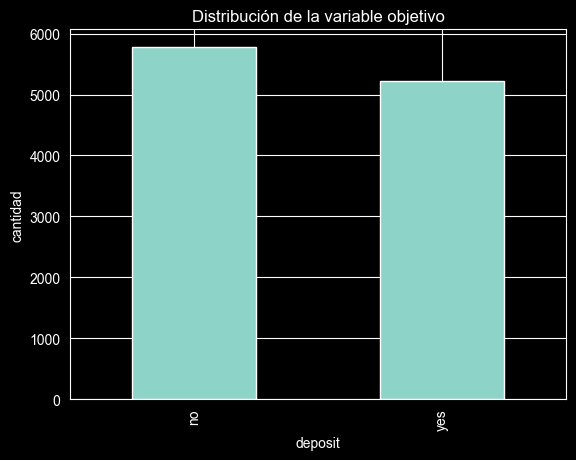

In [3]:
target = df_train['deposit'].tolist()

print(df_train['deposit'].dtype)


def label_plot(title, x, y):
    plt.title(title)
    plt.xlabel(x)
    plt.ylabel(y)


summary = pd.DataFrame({
    "Class": df_train['deposit'].value_counts().index,
    "Count": df_train['deposit'].value_counts().values,
    "Percentage": df_train['deposit'].value_counts(normalize=True).values * 100
})

show_df(summary)

df_train["deposit"].value_counts().plot(kind="bar")
label_plot('Distribución de la variable objetivo', 'deposit', 'cantidad')
plt.show()

La variable `deposit` presenta dos clases "yes" y "no", por lo que el problema es de clasificación binaria. La clase mayoritaria es "no", representando 52.54% de las instancias, mientras que "yes" representa el 47.45%. Por tanto, el conjunto de datos presenta un desbalance leve, que tendrá que tomarse en cuenta durante la evaluación de modelos.

## Esquema de Variables


In [4]:
summary = pd.DataFrame({
    "Feature": df_train.columns,
    "Semantic Type": df_train.dtypes,
    "Unique Values": df_train.nunique(dropna=True).tolist(),

})

summary = summary.sort_values("Semantic Type")

show_df(summary)

n = len(df_train)

constant_cols = df_train.columns[df_train.nunique() <= 1].tolist()
id_cols = df_train.columns[df_train.nunique() == n].tolist()

print("Constant columns:", constant_cols if constant_cols else "None")
print("Potential ID columns:", id_cols if id_cols else "None")

Feature,Semantic Type,Unique Values
age,int64,76
previous,int64,34
pdays,int64,472
campaign,int64,36
duration,int64,1423
balance,int64,3783
day,int64,31
month,object,12
contact,object,3
loan,object,2


Constant columns: None
Potential ID columns: None


Quitando deposit, tengo 16 features. 7 son números, 11 son variables de tipo object. Las variables object tienen pocos valores únicos, lo que me hace pensar que son categóricas. No hay ninguna variable constante ni de ID.

Procederé a analizarlas a mayor detalle, buscando entender como se distribuyen y en cuáles vale la pena indagar más a profundidad después.


### Variables Categóricas

Nos interesa saber su cardinalidad, si hay desbalances en las distribuciones, cúal es la categória dominante y si les faltan valores.

In [5]:
cat = df_train.select_dtypes(include="object")

rows = []

for col in cat.columns:
    freq = (cat[col].value_counts(dropna=False, normalize=True) * 100).round(2)
    categories = ["NaN" if pd.isna(x) else x for x in freq.index]
    dist = [f"({catg}, {pct}%)" for catg, pct in zip(categories, freq.tolist())]

    rows.append(", ".join(dist))

summary = pd.DataFrame({
    "Feature": cat.columns,
    "n_categories": cat.nunique(dropna=True).tolist(),
    "missing_values": cat.isnull().sum().tolist(),
    "missing_values %": (cat.isnull().mean() * 100).round(2).values,
    "category_distribution_top": rows,
})

summary = summary.sort_values("n_categories", ascending=False)

show_df(summary)

Feature,n_categories,missing_values,missing_values %,category_distribution_top
job,12,174,1.58,"(management, 22.52%), (blue-collar, 17.27%), (technician, 15.97%), (admin., 11.75%), (services, 8.27%), (retired, 6.82%), (self-employed, 3.59%), (student, 3.22%), (unemployed, 3.08%), (entrepreneur, 2.88%), (housemaid, 2.45%), (NaN, 1.58%), (unknown, 0.6%)"
month,12,0,0.00,"(may, 25.27%), (aug, 13.64%), (jul, 13.59%), (jun, 10.95%), (nov, 8.45%), (apr, 8.23%), (feb, 6.94%), (oct, 3.52%), (jan, 3.11%), (sep, 2.85%), (mar, 2.46%), (dec, 0.99%)"
education,4,0,0.00,"(secondary, 49.03%), (tertiary, 33.0%), (primary, 13.48%), (unknown, 4.49%)"
poutcome,4,0,0.00,"(unknown, 74.59%), (failure, 10.98%), (success, 9.63%), (other, 4.8%)"
marital,3,340,3.09,"(married, 55.26%), (single, 30.39%), (divorced, 11.25%), (NaN, 3.09%)"
contact,3,0,0.00,"(cellular, 72.02%), (unknown, 20.99%), (telephone, 6.99%)"
default,2,0,0.00,"(no, 98.48%), (yes, 1.52%)"
housing,2,0,0.00,"(no, 52.74%), (yes, 47.26%)"
loan,2,0,0.00,"(no, 86.99%), (yes, 13.01%)"
deposit,2,0,0.00,"(no, 52.55%), (yes, 47.45%)"


Observaciones:
* `default` tiene una distribución extremadamente concentrada en "no" (98.5%). Esto sugiere una baja variabilidad y potencialmente una utilidad predictiva limitada. No conviene eliminarla automáticamente, pero sí tener presente que aporta muy poca diversidad.
* `job` y `marital` tienen valores nulos: Las analizaremos a mayor profundidad para saber como tratarlas.
* `job`, `education`, `contact` y `poutcome` tienen "unknown" como clases. Hay que analizar su valor semántico par saber si tratarlos como información no disponible o un valor nulo, esa decir una categória o un missing imputable.
* `month` y `job` tienen 12 categorías diferentes, esto no es cardinalidad extrema, podemos hacer encoding categórico sin problema.
    * Aunque tengan valores con poca presencia, como "dec" en `month` y "housemaid" en `job`, no son suficientemente pequeños como para tener que agruparlos inmediatamente.

Cabe recalcar que `poutcome` está dominada por la categória "unknown" (74.6%), lo que nos indica que para la mayoría de observaciones no hay información concisa. Esto puede reducir su utilidad.

Basado en estos datos, clasificaría las variables de la siguiente manera:
* **Sin Incidencia Particular:** `housing`, `loan`
* **Variables Binarias Muy Desbalanceadas:** `default`
* **Variables Ambiguas ("unknown"):** `job`, `education`, `contact`, `poutcome`
* **Variables con Valores Nulos:** `job`, `marital`
* **Variables con Alta Cardinalidad:** `month`, `job`



### Variable Numéricas

Nos interesa saber la distribución de las variables, sus rangos y si tienen valores extremos.

In [6]:
num = df_train.select_dtypes(include="number")


def outlier_info_iqr(series):
    s = series.dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (s < lower) | (s > upper)

    return {
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower bound": lower,
        "Upper bound": upper,
        "Outliers": mask.sum(),
        "Outliers (%)": mask.mean() * 100
    }


summary = pd.DataFrame({
    "Feature": num.columns,
    "Min": [num[col].min() for col in num.columns],
    "Max": [num[col].max() for col in num.columns],
    "Range": [num[col].max() - num[col].min() for col in num.columns],
    "STD": [num[col].std() for col in num.columns],
    "Skewness": [num[col].skew() for col in num.columns],
    "Kurtosis": [num[col].kurtosis() for col in num.columns],
    "Mean": [num[col].mean() for col in num.columns],
    "Median": [num[col].median() for col in num.columns],
})

show_df(summary)

outlier_table = pd.DataFrame([
    {"Feature": col, **outlier_info_iqr(num[col])}
    for col in num.columns
])

show_df(outlier_table.sort_values("Outliers (%)", ascending=False))

Feature,Min,Max,Range,STD,Skewness,Kurtosis,Mean,Median
age,18,95,77,11.94,0.86,0.62,41.25,39.00
balance,-6847,81204,88051,3217.40,8.25,128.57,1529.14,549.50
day,1,31,30,8.42,0.11,-1.06,15.66,15.00
duration,2,3881,3879,347.52,2.14,7.29,372.52,255.00
campaign,1,63,62,2.72,5.57,57.87,2.51,2.00
pdays,-1,854,855,108.78,2.46,6.90,51.31,-1.00
previous,0,58,58,2.28,7.43,109.01,0.83,0.00


Feature,Q1,Q3,IQR,Lower bound,Upper bound,Outliers,Outliers (%)
pdays,-1.00,20.25,21.25,-32.88,52.12,2711,24.65
previous,0.00,1.00,1.00,-1.50,2.50,1234,11.22
balance,122.75,1711.00,1588.25,-2259.62,4093.38,1043,9.48
duration,138.00,498.00,360.00,-402.00,1038.00,620,5.64
campaign,1.00,3.00,2.00,-2.00,6.00,589,5.35
age,32.00,49.00,17.00,6.50,74.50,171,1.55
day,8.00,22.00,14.00,-13.00,43.00,0,0.00


Observaciones:
* Las variables numéricas no están en la misma escala. `balance` tiene un rango y desviación mayor que el resto. `campaign`, `previous` o `day` tienen escalas más reducidas. Esto sugiere que, si se utilizan modelos sensibles a distancias o magnitudes, será necesario aplicar escalado.
* `duration`, `balance`, `previous` y `campaign` muestran una asimetría positiva y una curtosis elevada.
    * En `previous` y `campaign` sugiere que la mayoría de observaciones se concentran en valores bajos.
    * `duration` presenta estas características de forma menos extrema que las otras. Aun así, la diferencia entre media y mediana y su porcentaje de outliers indican que conviene tenerla en cuenta como variable potencialmente problemática.
* `balance` es la variable numérica más extrema desde el punto de vista distributivo. Podemos observar una distribución sesgada a la derecha con presencia de valores altos poco frecuentes.
* `pdays` requiere una interpretación diferente. Esta variable no debe interpretarse como una numérica ordinaria, ya que contiene el valor -1, que actúa como código especial. Por tanto, parte de su comportamiento estadístico puede deberse a esa codificación.
* `age` muestra una distribución relativamente estable en comparación con el resto. Aunque presenta sesgo positivo y valores extremos según el IQR, de igual manera su comportamiento es mucho más moderado.
* `day` es la variable más regular del conjunto. Tiene asimetría baja, curtosis negativa y no presenta outliers, no parece plantear problemas a nivel distributivo.

Las variables que requieren mayor atención son `balance`, `previous`, `campaign`, `duration` y especialmente `pdays`, ya sea por su asimetría, por sus valores extremos o semántica especial. En cambio, `age` y `day` parecen menos problemáticas desde el punto de vista estructural.

## Correlación de Los Predictores con La Variable Objetivo

Después de haber hecho el barrido de las variables, nos conviene saber realmente que variables influencian la variable objetivo `deposit`.

### Variables Numéricas


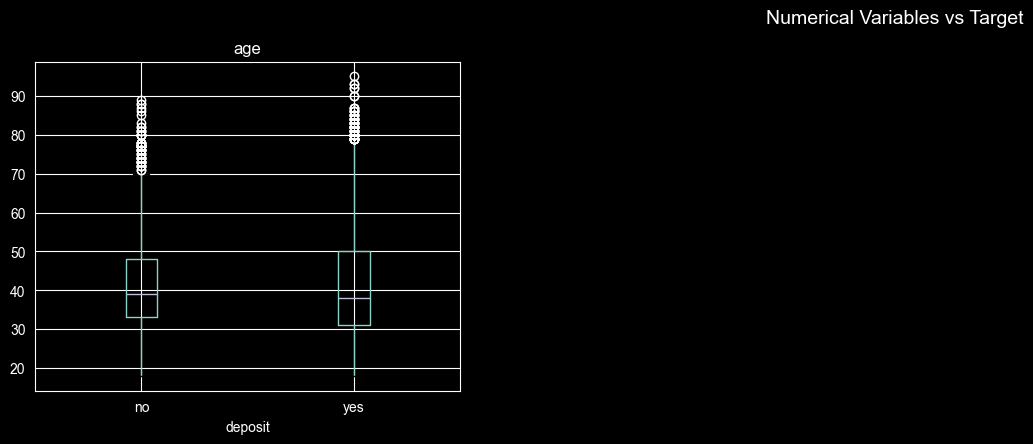

Feature,mean (no),mean (yes),difference (yes - no)
balance,1279.10,1806.00,526.90
duration,223.17,537.90,314.74
pdays,35.48,68.84,33.36
day,16.12,15.15,-0.98
age,40.85,41.70,0.85
campaign,2.84,2.14,-0.70
previous,0.52,1.17,0.65


In [7]:
num_cols = df_train.select_dtypes(include="number").columns.tolist()

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df_train.boxplot(column=col, by="deposit", ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("deposit")

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

plt.suptitle("Numerical Variables vs Target", fontsize=14)
plt.tight_layout()
plt.show()

mean_by_class = df_train.groupby("deposit")[num_cols].mean().T
mean_by_class.columns = ["mean (no)", "mean (yes)"]
mean_by_class["difference (yes - no)"] = mean_by_class["mean (yes)"] - mean_by_class["mean (no)"]
mean_by_class["abs_diff"] = mean_by_class["difference (yes - no)"].abs()
mean_by_class = mean_by_class.sort_values("abs_diff", ascending=False).drop(columns="abs_diff")

show_df(mean_by_class.reset_index().rename(columns={"index": "Feature"}))

Observaciones:
* La variable más influyente es `duration` (confirmado en la tabla: media 538 vs. 223), los clientes que más se subscriben tienen llamadas más largas. Predictor fuerte.
* Los clientes "si" tienen un `balance` parcialmente mayor (1806 vs. 1279). Es una señal moderada, tiene muchos outliers.
* `age` las boxes están casi superpuestas y la diferencia es de 0.85 años, es básicamente inútil como predictor autónomo.
* `day` prácticamente idéntico, no es predictivo.
* `campaign` los clientes "no" fueron contactados más (2.84 vs. 2.14). Podemos interpretar que si tuviste que llamar a alguien múltiples veces, entonces no tenían interés.
* `pdays`, dominada por él -1, voy a tener que analizarla más a detalle.
* `previous`, dominada por el 0, la mayoría de clientes no fueron contactados antes de esta campaña.

### Variables Categóricas

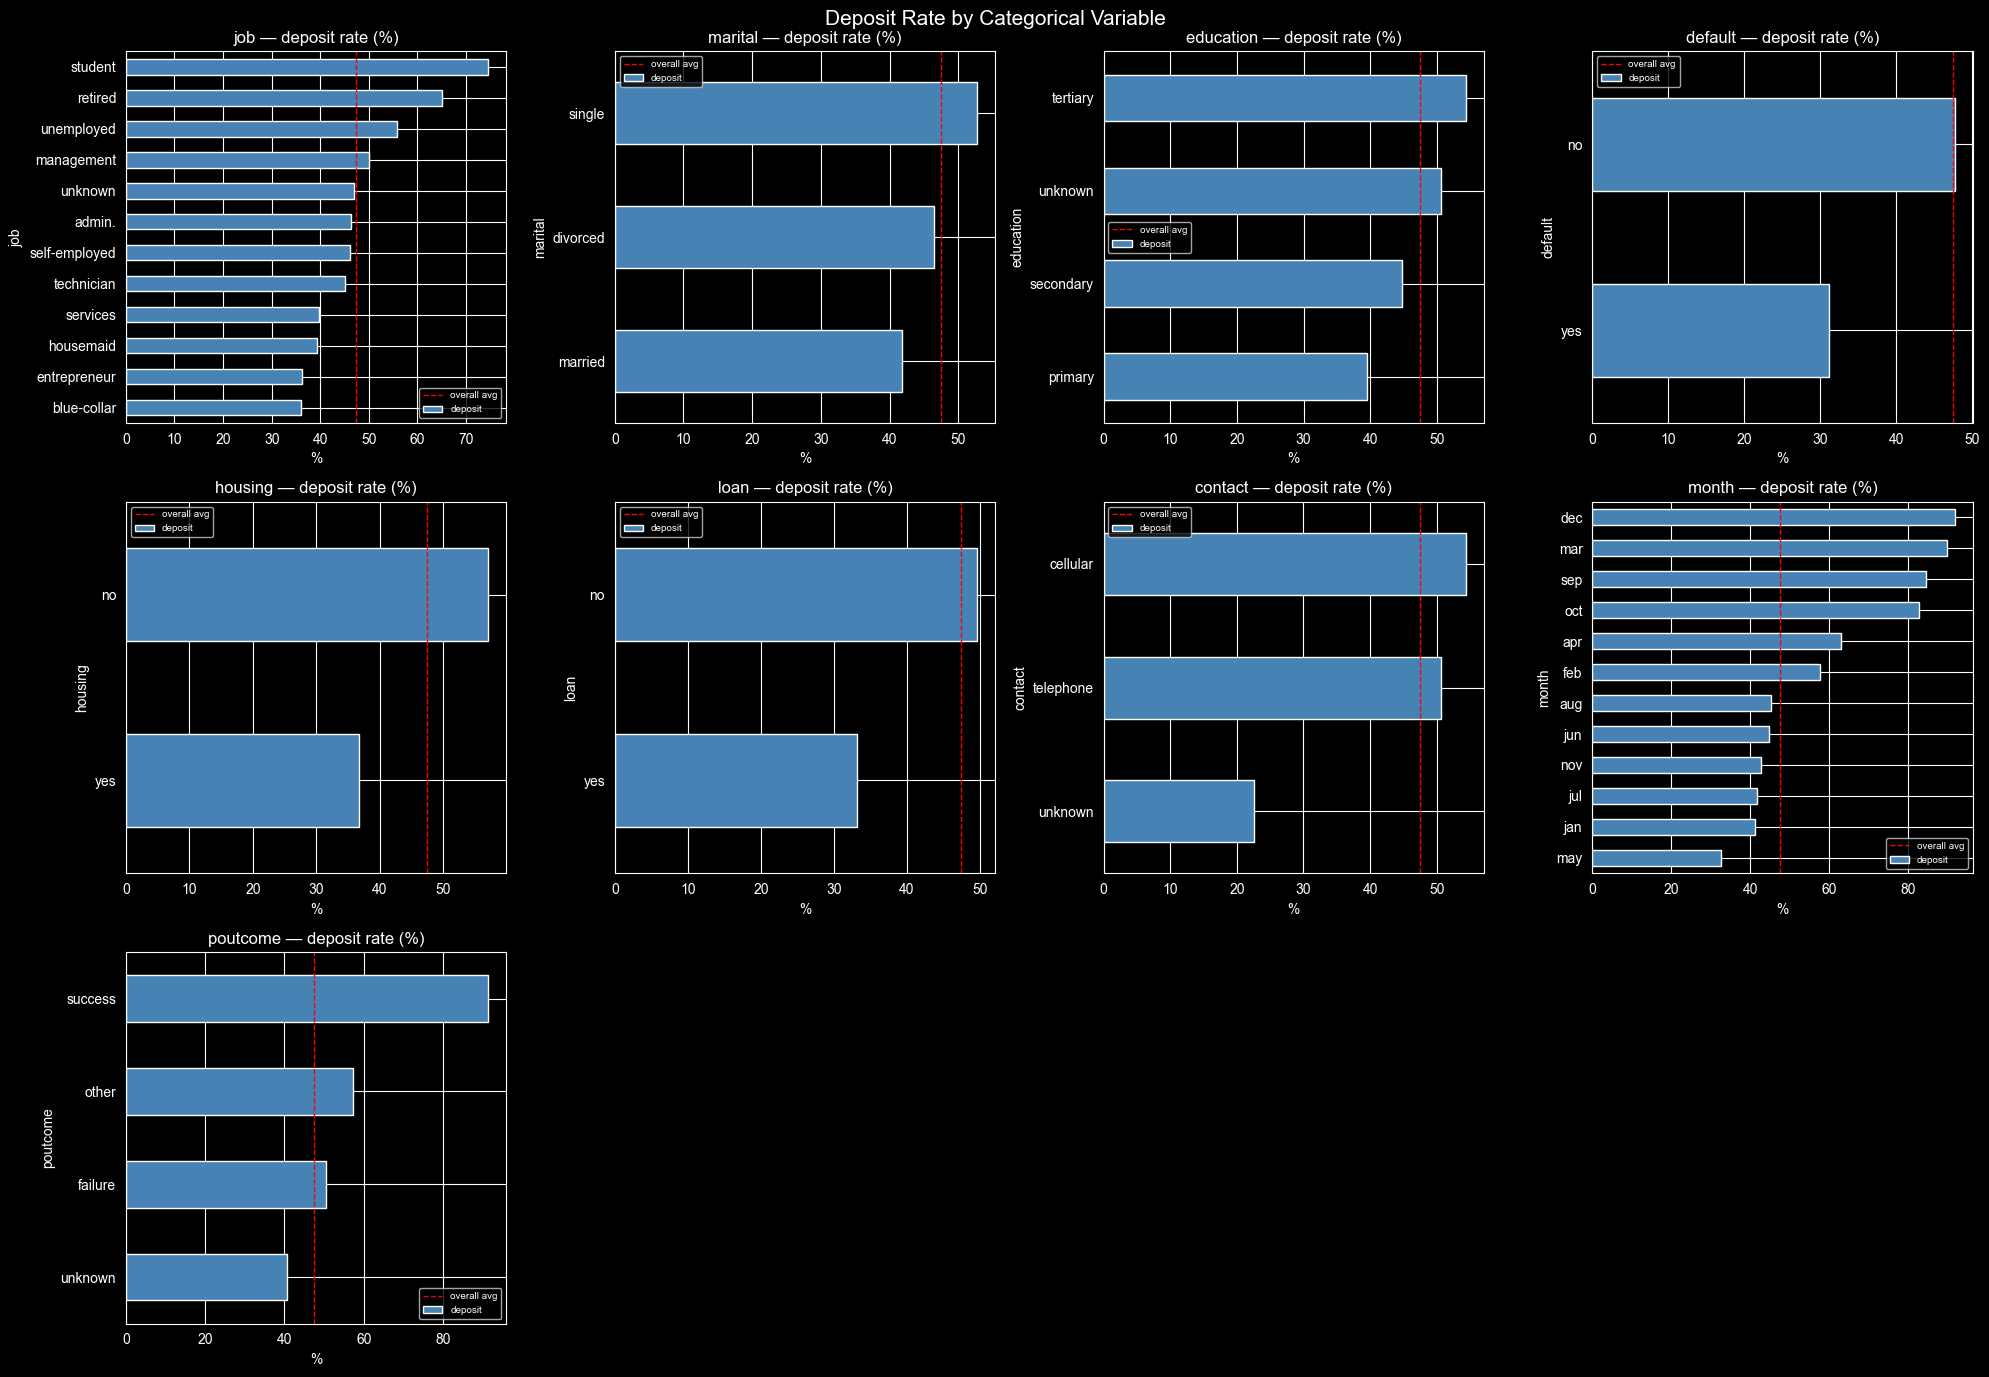

In [8]:
cat_cols = [c for c in df_train.select_dtypes(include="object").columns if c != "deposit"]

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    rate = df_train.groupby(col)["deposit"].apply(lambda x: (x == "yes").mean() * 100).sort_values()
    rate.plot(kind="barh", ax=axes[i], color="steelblue")
    axes[i].set_title(f"{col} — deposit rate (%)")
    axes[i].set_xlabel("%")
    axes[i].axvline(x=(df_train["deposit"] == "yes").mean() * 100,
                    color="red", linestyle="--", linewidth=1, label="overall avg")
    axes[i].legend(fontsize=7)

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Deposit Rate by Categorical Variable", fontsize=15)
plt.tight_layout()
plt.show()

Observaciones:
* `poutcome`, la variable más fuerte. El éxito de una campaña anterior predice la subscripción muy bien (~85%). Aunque 74% sea "unknown", la señal de las categorías conocidas es decisiva.
* `contact` es fuerte. La mayoría de los clientes que se subscriben usan un celular. Si son difíciles de contactar, y usamos un método "unknown", entonces probablemente no se subscriban.
* `mortage` da buena señal. Clientes sin hipoteca o sin casa se suelen subscribir más.
* `month` aunque diciembre de señales fuertes, hay que recordar que solo representa el 1% de los meses. En los meses más presentes (may, jul, aug, jun, nov) tenemos señales reales. Mayo es bastante bajo (~30%), y constituye 25% de la data, esto es un indicativo.
* `job`, estudiantes y retirados están por encima de la media, blue-collar por debajo. Son categorías significativas.
* `education` no tiene mucha diferencia entre sus clases, es un predictor marginal.
* `marital` y `loan`, tienen pocas diferencias, probablemente no sea útil.
* `default` es prácticamente constante, entonces no podemos sacar conclusiones reales.


De estas variables categóricas `poutcome`, `contact`, `housing` y `month` tienen la mayor relación con `deposit`. `job` tiene una relación más moderada. `marital`, `loan` y `default` parecen tener poco valor predictivo. Sin embargo, estás conclusiones se basan en distribuciones marginales, la importancia de cada variable la veremos en el modelado.


### Revisión de pdays

Never contacted before: 8203 (74.6%)
Contacted before: 2797 (25.4%)

For those contacted before:
count    2797.00
mean      204.72
std       122.40
min         1.00
25%        98.00
50%       182.00
75%       286.00
max       854.00
Name: pdays, dtype: float64

Deposit rate — contacted before: 67.3%
Deposit rate — NOT contacted before: 40.7%


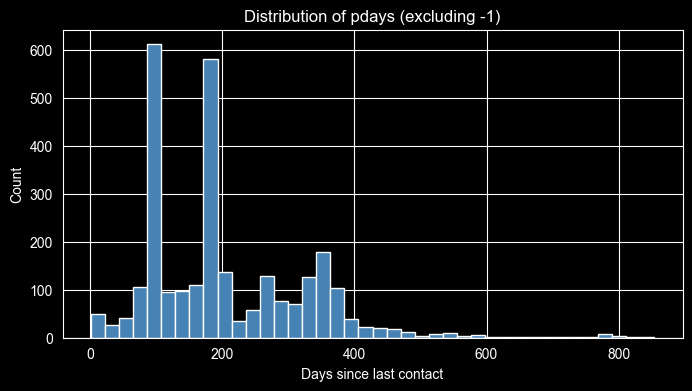

In [9]:
# pdays: -1 means "not contacted in previous campaign"
pdays_contacted = df_train[df_train["pdays"] != -1]["pdays"]
pdays_not_contacted = df_train[df_train["pdays"] == -1]

print(f"Never contacted before: {len(pdays_not_contacted)} ({len(pdays_not_contacted)/len(df_train)*100:.1f}%)")
print(f"Contacted before: {len(pdays_contacted)} ({len(pdays_contacted)/len(df_train)*100:.1f}%)")
print(f"\nFor those contacted before:")
print(pdays_contacted.describe().round(2))

# Deposit rate split: contacted vs not contacted before
rate_contacted = (df_train[df_train["pdays"] != -1]["deposit"] == "yes").mean() * 100
rate_not_contacted = (df_train[df_train["pdays"] == -1]["deposit"] == "yes").mean() * 100

print(f"\nDeposit rate — contacted before: {rate_contacted:.1f}%")
print(f"Deposit rate — NOT contacted before: {rate_not_contacted:.1f}%")

# Distribution of actual pdays values (excluding -1)
plt.figure(figsize=(8, 4))
pdays_contacted.hist(bins=40, color="steelblue", edgecolor="white")
plt.title("Distribution of pdays (excluding -1)")
plt.xlabel("Days since last contact")
plt.ylabel("Count")
plt.show()

En `pdays` él -1 representa usuarios que no fueron contactados en una campaña anterior, al quitarlo obtenemos unos datos interesantes. Podemos observar que en géneral usuarios que fueron contactados anteriormente suelen subscribirse más que usuarios que no fueron contactados anteriormente. Haber sido contactado en una campaña previa es uno de los indicativos más fuertes de nuestro dataset para la predicción. Esto tiene sentido intuitivo, si el banco ya tiene una relación contigo, eres más capaz de inscribirte a su plan de depósito.

Además, vemos algo curioso, el pico de días desde el último contacto son 100 y 180, esto nos muestra un poco como son los ciclos de campaña del banco, aunque no nos proporciona información relevante para el modelo. Solo un dato curioso.

Existen outliers, hay clientes que no se han contactado en ~850 días, pero esto no son errores, es data real.

## Conclusiones del EDA
Después de haber analizado la variable objetivo, la estructura y distribución de las variables, y su correlación con el objetivo, podemos extraer multiples conclusiones.

1. La variable objetivo `deposit` es de tipo categórica binaria, con dos clases "si" y "no", y está relativamente balanceada (47/~53). Esto nos indica que probablemente deberíamos usar `StratifiedKFold` para la cross-validation, así mantenemos el balance de las clases en los folds.

2. Nuestro mejor predictor numérico es `duration`, ya que tiene la mayor correlación con el éxito de subscripción por parte los usuarios. Esto tiene sentido, mientras más larga la llamada, más probable es que se inscriban.
    <br>&nbsp;&nbsp;Sin embargo, tenemos que tomar en cuenta que en un entorno real esta variable no se conoce antes de realizar la llamada. Podemos asumir que el caso práctico del banco es llamar a los clientes con más probabilidad de subscripción, pero en este caso la duración no existe.
    <br>&nbsp;&nbsp;Aun así, mantendremos la variable, ya que se usa para evaluar en la competencia y queremos hacer la mejor predicción, en un entorno laboral y no de competencia habría que hablar con el equipo y definir si se va a considerar esta variable o no.

3. `poutcome` es 74% "unknown". Sin embargo, cuando es "success" la tasa de subscripción es 85%. Esto nos muestra que "unknown" es una clase válida, si la tomamos como valor faltante y la imputamos con "success", "failure" u "other", dañamos la generalización.

4. La variable `default` es 98.5% "no". Probablemente, no vaya a ayudar a los modelos demasiado y puede ser un candidato de eliminación si el modelo sobre-ajusta, pero por ahora la mantengo.

## Implicaciones para El Pre-procesado

1. Manejo de `pdays`.
    * El problema: -1 es un código, no un número. Incluirlo confundiría modelos como KNN o Modelos Lineales porque -1 es cercano a 1 día, cuando en realidad tiene un valor semántico implícito.
    * La solución: Crear un transformador booleano. La trataríamos como una variable mixta.
        * Creamos un nuevo feature `pdays_contacted`. Es binario, 1 si `pdays != -1` sino 0.
        * Reemplazamos -1 con un valor neutro, como 0 o la media, después de crear el feature binario.
                * El problema con esto es que con 0 podemos interpretarlo como que lo venimos de contactar y la media puede asignar a personas que no hemos contactado la media. Entonces voy a usar un `FunctionTransformer` o un pipeline personalizado, ya que en KNN hay que imputar, pero en árboles no.

2. Encoding categórico:
    * One-Hot Encoding (OHE): Lo usamos para `marital`, `education`, `poutcome`, `contact`, `housing`, `loan` y `default`.
    * Alta Cardinalidad: Para `job` y `month`, OHE sigue funcionando (12 categorías cada uno), pero hay que asegurarnos de usar `handle_unknown='ignore'` en nuestro encoder para prevenir que falle si el test tiene "unknown".

3. Escalado Numérico:
    * Usaremos `RobustScaler`, ya que `balance`, `duration` y `campaign` tienen outliers pesados (como vimos en los box-plots), y este scaler los maneja mejor que `StandardScaler`. Este usa el mediano y el IQR, haciéndolo menos sensible a los extremos. De igual manera probaremos los otros scalers con CV para asegurarnos que escojamos el mejor.

4. Imputación:
    * Para `job` y `marital` (las únicas que tienen NaN) usaremos un `SimpleImputer(strategy='most_frequent')` o una constante (e.g. "missing").

# Pre-Procesado

## Partición de Cross-Validation (CV)

Comó las clases de `deposit` están balanceadas (47-53), podríamos usar **Accuracy**, pero **ROC-AUC** tiene más sentido, esté mide que tan bien nuestro modelo categoriza positivos sobre negativos. El banco probablemente le interesa más saber que clientes dirán que sí.


In [10]:
# Initial config.
NIA_SEED = 100502359
np.random.seed(NIA_SEED)

# Holdout
X = df_train.drop('deposit', axis=1)
y = df_train['deposit'].map({'yes': 1, 'no': 0}) # Numeric mapping for ROC-AUC
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=NIA_SEED, stratify=y)

Ahora definimos las variables que vamos a usar en el pipeline.

In [11]:
num_vars = ['age', 'balance', 'day', 'duration', 'campaign', 'previous', 'pdays']
cat_vars = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

## Scaling

Antes de empezar, veamos realmente cuál es el mejor scaler. Ya deduje que `RobustScaler` iba a ser el mejor, pero veámoslo rápidamente. Tomaré un valor de K para KNN y probaré tres scalers.

In [12]:
# pdays cleaner
def basic_cleaning(x_input):
    x_out = x_input.copy()

    # Binary flag
    x_out['was_contacted'] = (x_out['pdays'] != -1).astype(int)
    x_out['pdays'] = x_out['pdays'].replace(-1, 0)
    return x_out

# Using KNN with K=7
scalers = {'MinMax': MinMaxScaler(), 'Standard': StandardScaler(), 'Robust': RobustScaler()}
scaler_results = []

for name, s in scalers.items():
    # Temporal pipeline
    prep_temp = ColumnTransformer([
        ('num', s, num_vars),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_vars)
    ], remainder='passthrough')
    pipe_temp = Pipeline([
        ('clean', FunctionTransformer(basic_cleaning)),
        ('prep', prep_temp),
        ('knn', KNeighborsClassifier(n_neighbors=7))
    ])
    # Using ROC-AUC
    scores = cross_val_score(pipe_temp, X_train, y_train, cv=5, scoring='roc_auc')
    scaler_results.append({'Scaler': name, 'ROC-AUC': scores.mean(), 'Std Dev': scores.std()})

summary = pd.DataFrame(scaler_results).sort_values(by='ROC-AUC', ascending=False)
summary['Stability (%)'] = (summary['Std Dev'] / summary['ROC-AUC']) * 100
show_df(summary)


Scaler,ROC-AUC,Std Dev,Stability (%)
Standard,0.88,0.01,0.76
Robust,0.86,0.01,0.85
MinMax,0.81,0.01,1.21


Podemos observar que `MinMaxScaler` tuvo el peor rendimiento, esto es de esperar, ya que es sensible a valores extremos y nuestra data tiene muchos.

Aunque las deducciones del EDA sugerían el uso de `RobustScaler` por la presencia de valores extremos, el resultado de la validación cruzada muestran que `StandardScaler` es superior. No solo obtiene un ROC-AUC mayor (0.88), sino que presenta mejor estabilidad (0.76%). Esto sugiere que los valores extremos en variables como 'duration' o 'balance' contienen información valiosa que `StandardScaler` preserva mejor.

Hagamos entonces un pipeline de pre-procesado.

In [16]:
# Machine for Numbers (Impute -> Scale)
num_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])

# Machine for Words (Impute -> Encode)
cat_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('encode', OneHotEncoder(handle_unknown='ignore'))
])

# Machine for pdays (Custom Function -> Scale)
pdays_pipeline = Pipeline([
    ('custom', FunctionTransformer(basic_cleaning)),
    ('scale', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('num_part', num_pipeline, num_vars),
    ('cat_part', cat_pipeline, cat_vars),
    ('pdays_part', pdays_pipeline, ['pdays'])
])

# KNN y Árboles

## KNN

## Feature Engineering

Antes de empezar el pipeline, podemos crear algunos features para dar más contexto a nuestro modelo.
1. **Recency Success**: La idea es combinar `poutcome` y `pdays`. Un éxito de una campaña es más valioso mientras más reciente es. Un éxito de hace dos años no es igual de valioso que uno reciente.
2. **Debt Load**: Una variable ordinal (0, 1, 2) que suma si un cliente tiene hipoteca y/o préstamos. La hipótesis es que a mayor carga de deuda, menor la liquidez para abrir un plan de depósito.
3. `pdays` **Cleaning**: La idea es hacer la separación de la señal en una parte binaria y númerica.

Lo que haremos entonces es probar la versión básica (con los features iniciales) vs. la versión mejorada (con los features adicionales), para ver si realmente ganamos algo. Ambas versiones tendrán el arreglo de `pdays` ya que sino la comparación no sería justa.

In [15]:
def add_custom_features(x_input):
    x_out = x_input.copy()

    # Recency Success
    # We replace -1 for 999 to avoid zero division
    x_out['recency_success'] = (x_out['poutcome'] == 'success').astype(int) / (x_out['pdays'].replace(-1, 999) + 1)

    # Debt Load
    x_out['debt_load'] = (x_out['housing'] == 'yes').astype(int) + (x_out['loan'] == 'yes').astype(int)

    return x_out

SCALER = StandardScaler()

num_vars_enhanced = num_vars + ['recency_success', 'debt_load']

prep_base = ColumnTransformer([
    ('num', SCALER, num_vars),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_vars)
])

prep_enhanced = ColumnTransformer([
    ('num', SCALER, num_vars_enhanced),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_vars)
], remainder='passthrough') # Let 'was_contacted' pass

# Experiment dictionary
fe_experiments = {
    'KNN (Base)': Pipeline([
        ('clean', FunctionTransformer(basic_cleaning)),
        ('prep', prep_base),
        ('clf', KNeighborsClassifier(n_neighbors=7))
    ]),
    'KNN (Enhanced)': Pipeline([
        ('clean', FunctionTransformer(basic_cleaning)),
        ('fe', FunctionTransformer(add_custom_features)),
        ('prep', prep_enhanced),
        ('clf', KNeighborsClassifier(n_neighbors=7))
    ]),
    'Tree (Base)': Pipeline([
        ('clean', FunctionTransformer(basic_cleaning)),
        ('prep', prep_base),
        ('clf', DecisionTreeClassifier(max_depth=5, random_state=NIA_SEED))
    ]),
    'Tree (Enhanced)': Pipeline([
        ('clean', FunctionTransformer(basic_cleaning)),
        ('fe', FunctionTransformer(add_custom_features)),
        ('prep', prep_enhanced),
        ('clf', DecisionTreeClassifier(max_depth=5, random_state=NIA_SEED))
    ])
}

fe_results = []
for name, pipe in fe_experiments.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='roc_auc')
    fe_results.append({'Config': name, 'ROC-AUC': scores.mean(), 'Std Dev': scores.std()})

summary = pd.DataFrame(fe_results).sort_values(by='ROC-AUC', ascending=False)
show_df(summary)

Config,ROC-AUC,Std Dev
KNN (Base),0.88,0.01
KNN (Enhanced),0.88,0.01
Tree (Enhanced),0.85,0.01
Tree (Base),0.85,0.00
